# Experiments with DIFFI

With this notebook we want to test how many and which of the important features have been exploited by each isolation tree in a given isolation forest.

## Imports & Initializations

In [1]:
import os
import numpy as np
import pickle as pkl 
import matplotlib.pyplot as plt 
%matplotlib inline
# from sklearn.ensemble import IsolationForest
# from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler 
# import shap
# import diffi.interpretability_module as interp
from diffi.utils import *
import wandb
import pandas as pd
import odds_datasets
import seaborn as sns

/Users/sebastianosanson/Documents/Master Thesis/Master-Thesis/mt_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: sanson-sebastiano-00 (sanson-sebastiano-00-universita-di-padova) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
np.random.seed(0)

## Dataset

### Synthetic Dataset

In [4]:
n_features = 20   # Total number of features
n_meaningful = 2  # Number of meaningful features

# Parameters
n_regular = 900  # Number of regular data points
n_anomalous = 100  # Number of anomalous data points

In [5]:
def generate_syn_dataset():
    # Generate regular data
    rho_regular = np.random.uniform(0, 3, n_regular)
    theta_regular = np.random.uniform(0, 2 * np.pi, n_regular)
    meaningful_regular = np.column_stack((rho_regular * np.cos(theta_regular), 
                                        rho_regular * np.sin(theta_regular)))

    # Generate anomalous data
    rho_anomalous = np.random.uniform(4, 30, n_anomalous)
    theta_anomalous = np.random.uniform(0, 2 * np.pi, n_anomalous)
    meaningful_anomalous = np.column_stack((rho_anomalous * np.cos(theta_anomalous), 
                                            rho_anomalous * np.sin(theta_anomalous)))

    # Combine meaningful features
    meaningful_features = np.vstack((meaningful_regular, meaningful_anomalous))

    # Generate noise features
    noise_features = np.random.normal(0, 1, (n_regular + n_anomalous, n_features - n_meaningful))

    # Combine meaningful and noise features
    data = np.hstack((meaningful_features, noise_features))

    # Create labels (0 for regular, 1 for anomalous)
    labels = np.array([0] * n_regular + [1] * n_anomalous)

    contamination = n_anomalous / (n_regular + n_anomalous)

    return data, labels, contamination

# columns = [f"Feature_{i+1}" for i in range(n_features)]
# train_df = pd.DataFrame(data, columns=columns)
# train_df['Label'] = labels

# print(train_df.head())

In [6]:
# plt.figure(figsize=(10, 6))
# plt.scatter(train_df[train_df['Label'] == 0]['Feature_1'], train_df[train_df['Label'] == 0]['Feature_2'], 
#             label='Regular', alpha=0.6, c='blue')
# plt.scatter(train_df[train_df['Label'] == 1]['Feature_1'], train_df[train_df['Label'] == 1]['Feature_2'], 
#             label='Anomalous', alpha=0.6, c='red')

# plt.xlabel('Feature_1')
# plt.ylabel('Feature_2')
# plt.title('Scatter Plot of the Dataset')
# plt.legend()
# plt.show()

# train_set = np.column_stack((data, labels))

# Parameters

Parameters for the model

In [7]:
num_trees = 100
max_samples = 256
n_forests = 1
usage_threshold = [0.1]     # shape: (n_seed)

## Functions definitions

In [8]:
def log_model_config(contamination):
    """
    Log the model configuration parameters to wandb.
    """
    config_data = [
        ["num_trees", num_trees],
        ["max_samples", max_samples],
        ["contamination", contamination],
    ]

    config_table = wandb.Table(data=config_data, columns=["Parameter", "Value"])

    wandb.log({"Configuration Table": config_table})

    # # table for n_forests and usage_threshold
    # data = [[f"Forest {i+1}", usage_threshold[i]] for i in range(n_forests)]
    # columns = ["Forest", "Usage Threshold"]

    # usage_threshold_table = wandb.Table(data=data, columns=columns)

    # # Log the table to wandb
    # wandb.log({"Usage Threshold Table": usage_threshold_table})

Plotting the feature importance values for each feature

In [9]:
def log_feature_importance(feature_rank, fi_means, fi_std, og_model: bool):
    """
    Plot and log the feature importance to wandb.
    """
    
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(feature_rank)), fi_means[feature_rank], yerr=fi_std[feature_rank])
    plt.xticks(range(len(feature_rank)), feature_rank)
    plt.xlabel('Feature index')
    plt.ylabel('Feature importance')
    if og_model:
        plt.title('Feature importance on original model')
        wandb.log({"original_model_feature_importance_image": wandb.Image(plt)})
    else:
        plt.title('Feature importance on new model')
        wandb.log({"new_model_feature_importance_image": wandb.Image(plt)})

    # plt.show()

Plotting the heatmap of feature importance for every trees 

In [10]:
def log_feature_importance_heatmap(fi_diffi, for_inliers: bool):
    """
    Log the feature importance heatmap to wandb.
    """
    for i, forest in enumerate(fi_diffi):
        plt.figure(figsize=(12, 8))
        plt.plot(1, len(fi_diffi), i + 1)
        sns.heatmap(forest, cmap='viridis', cbar=True, vmin=0, vmax=0.16)
        plt.xlabel('Feature Index')
        plt.ylabel('Tree Index')
        # plt.tight_layout()
        if for_inliers:
            plt.title(f'Feature Importance Heatmaps for Inliers - Forest {i + 1}', fontsize=16)
            wandb.log({"feature_importance_heatmap_inliers": wandb.Image(plt)})
        else:
            plt.title(f'Feature Importance Heatmaps for Outliers - Forest {i + 1}', fontsize=16)
            wandb.log({"feature_importance_heatmap_outliers": wandb.Image(plt)})
            
        # plt.show()

Counting how many times the features are used in each Isolation Tree

In [11]:
def feature_usage(features_per_forest, num_features):
    """
    Computing and plotting the feature usage in each tree and forest.
    """
    usage_per_forest = np.zeros((n_forests, num_features), 
                                dtype=object)    # shape: (number of forests, number of features)
    usage_per_tree = np.zeros((n_forests, num_trees, num_features), 
                            dtype=object)       # shape: (number of forests, number of trees, number of features)


    for i in range(num_features):                                                       # for each feature                                     
        for j, forest in enumerate(features_per_forest):                                # for each forest
            for k, tree in enumerate(forest):                                           # for each tree
                # count the number of times feature i is used in tree k in forest j
                usage_per_tree[j, k, i] = np.sum([1 for feature in tree if feature == i])   
            # count the number of times feature i is used in forest j
            usage_per_forest[j, i] = np.sum(usage_per_tree[j, :, i])                          

    # print(np.array(usage_per_forest, dtype=object).shape)
    # print(np.array(usage_per_tree, dtype=object).shape)

    plt.figure(figsize=(12, 6))
    for i in range(usage_per_forest.shape[0]):
        plt.bar(range(usage_per_forest.shape[1]), usage_per_forest[i], alpha=0.5, label=f'Forest {i+1}')
    plt.xlabel('Feature Index')
    plt.ylabel('Usage Count')
    plt.title('Feature Usage Across Forests')
    plt.legend()
    plt.tight_layout()

    wandb.log({"feature_usage_image": wandb.Image(plt)})

    # plt.show()

    return usage_per_forest, usage_per_tree

Counting how many times the `most_important_features`are used in each Isolation Tree

In [ ]:
def most_important_feature_usage(most_important_features, usage_per_tree, features_per_forest):
    """
    Compute the usage of the most important features in each tree.
    """
    most_important_features_usage = np.zeros((len(most_important_features), 
                                                n_forests, num_trees))    # shape: (number of meaningful features, number of forests, number of trees)

    for i in range(len(most_important_features)):
        for j, forest in enumerate(features_per_forest):    
            for k, tree in enumerate(forest):
                most_important_features_usage[i, j, k] = usage_per_tree[j, k, i] / len(tree)

    print('Two most important features usage:', most_important_features_usage)

    # Normalize the usage of the most important features by min-max scaling
    most_important_feature_usage_scaled = np.zeros_like(most_important_features_usage)
    for i in range(len(most_important_features)):
        for j in range(n_forests):
            most_important_feature_usage_scaled[i, j, :] = (most_important_features_usage[i, j, :] - np.min(most_important_features_usage[i, j, :])) / \
                                                            (np.max(most_important_features_usage[i, j, :]) - np.min(most_important_features_usage[i, j, :]))
    
    print('Two most important features usage scaled:', most_important_feature_usage_scaled)

    # Plotting the usage of `most_important_features` across isolation trees
    plt.figure(figsize=(12, 6))
    for i, feature in enumerate(most_important_features):
        plt.subplot(1, 2, i+1)
        for j in range(n_forests):
            plt.bar(range(num_trees), most_important_feature_usage_scaled[i, j, :], alpha=0.5, label=f'Forest {j+1}')
        plt.xlabel('Tree Index')
        plt.ylabel('Usage')
        plt.title(f'Usage of Feature {feature}')
        plt.legend()
    plt.tight_layout()

    # run.log({"most_important_features_usage_image": wandb.Image(plt)})

    # plt.show()

    return most_important_feature_usage_scaled

Calculating the average of the average usage for each `most_important_features`

In [13]:
def average_usage(most_important_feature_usage_scaled, most_important_features, seed_idx, fi_means):
    """
    Compute the average usage of the most important features across forests.
    """
    
    # Compute the average usage percentage for each meaningful feature
    avg_usage = np.zeros((len(most_important_features), n_forests))    # shape: (number of meaningful features, number of forests)
    for i in range(len(most_important_features)):
        for j in range(n_forests):
            avg_usage[i, j] = np.mean(most_important_feature_usage_scaled[i, j, :])
    print('Average usage per meaningful features:', avg_usage)

    # wandb.log({"Average Usage across Meaningful Features": average_usage_percentage_across_features})

    data = [[f"Feature {most_important_features[i]}", f"Forest {j+1}", avg_usage[i, j]] for i in range(len(most_important_features)) for j in range(n_forests)]
    columns = ["Feature", "Forest", "Average Usage"]
    avg_usage_table = wandb.Table(data=data, columns=columns)
    wandb.log({"Average Usage across Meaningful Features": avg_usage_table})

    # Weighting the average usage by the feature importance
    # TODO: RAGIONA BENE SU QUESTO CODICE SOTTOSTANTE -> FORSE NON È NECESSARIO FARE ANCHE LA MEDIA SU TUTTE LE FORESTE PER CIASCUNA FEATURE
    partial_threshold = np.zeros((len(most_important_features)))    # shape: (number of meaningful features)
    for i in range(len(most_important_features)):
        partial_threshold[i] = np.mean(avg_usage[i, :]) 
    
    print('Partial threshold:', partial_threshold)

    threshold = np.mean(np.multiply(partial_threshold, fi_means))

    print('Threshold:', threshold)

    data = [[f"Seed {seed_idx}", threshold]]
    columns = ["Seed", "Threshold"]
    threshold_table = wandb.Table(data=data, columns=columns)
    wandb.log({"Threshold Table": threshold_table})

    # plotting the average usage percentage across all meaningful features

Now we are going to select the indexes of the trees to be removed from the original iForests

In [14]:
def removing_trees(most_important_features_usage_scaled, most_important_features, iforests, threshold):
    """
    Remove the trees with usage percentage less than the threshold.
    """
    
    # save indexes of the trees to be removed
    tree_idx = np.zeros((len(most_important_features), n_forests), dtype=object)  # shape: (number of meaningful features, number of forests)
    print(tree_idx.shape)

    for i, feature in enumerate(most_important_features_usage_scaled):
        for j, forest in enumerate(feature):
            tree_idx[i, j] = np.where(forest < threshold)[0]  # get the indexes of the trees where the usage percentage is less than usage_threshold
            print(f"Feature {most_important_features[i]} in Forest {j+1} has trees with usage percentage < {threshold}: {tree_idx[i, j]}")

    # Concatenating and removing duplicates
    tree_to_be_removed = np.zeros(n_forests, dtype=object)
    print(tree_to_be_removed.shape)

    for i in range(n_forests):
        # concatenate the indexes of the trees to be removed for each feature
        concatenated = np.concatenate(([feature[i] for feature in tree_idx]), axis=0)
        # print('concatenated: {}'.format(concatenated))
        # remove duplicates
        concatenated = np.unique(concatenated)
        # print('unique: {}'.format(concatenated))
        tree_to_be_removed[i] = concatenated

    print(tree_to_be_removed)
    print('Number of trees to be removed: ', [len(tree_to_be_removed[i]) for i in range(len(tree_to_be_removed))])

    # remove the trees from the forests
    for i, forest in enumerate(iforests):
        # print(f'Forest {i}:')
        
        # Get the list of trees and their corresponding features
        trees = forest.estimators_
        features = forest.estimators_features_

        # print(' Number of trees before removal:', len(trees))
        # print(' Number of features in trees before removal:', len(features))
        
        # Remove the specified trees and their features
        trees_to_keep = [tree for idx, tree in enumerate(trees) if idx not in tree_to_be_removed[i]]
        features_to_keep = [feature for idx, feature in enumerate(features) if idx not in tree_to_be_removed[i]]
        
        # Update the forest with the filtered lists
        forest.estimators_ = trees_to_keep
        forest.estimators_features_ = features_to_keep

        # Update internal attributes to match the reduced number of trees
        forest._decision_path_lengths = [forest._decision_path_lengths[idx] for idx in range(len(trees)) if idx not in tree_to_be_removed[i]]
        forest._average_path_length_per_tree = [forest._average_path_length_per_tree[idx] for idx in range(len(trees)) if idx not in tree_to_be_removed[i]]
        
        # print(' Number of trees after removal:', len(forest.estimators_))
        # print(' Number of features after removal:', len(forest.estimators_features_))

    print('Number of trees after removal: ', [len(iforests[i].estimators_) for i in range(len(iforests))])
    print('Number of features in trees after removal: ', [len(iforests[i].estimators_features_) for i in range(len(iforests))])
    print('Number of decision path lengths after removal: ', [len(iforests[i]._decision_path_lengths) for i in range(len(iforests))])
    print('Number of average path lengths after removal: ', [len(iforests[i]._average_path_length_per_tree) for i in range(len(iforests))])

This function computes the difference of the feature importance, for each features, between the original and new model

In [15]:
def compute_difference(fi_means, new_fi_means, sorted_idx):
    """
    Compute the difference in feature importance between the original and new model.
    """
    
    diff = []
    for idx in sorted_idx:
        diff.append(new_fi_means[idx] - fi_means[idx])
        
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(diff)), diff)
    plt.xticks(range(len(diff)), sorted_idx)
    plt.xlabel('Feature index')
    plt.ylabel('Difference in Feature Importance')
    plt.title('Difference in Feature Importance')
    # 
    wandb.log({"difference_feature_importance_image": wandb.Image(plt)})

    # plt.show()

## Launch experiments

Seed: 0

Training set size:  (900, 20)
Trainin label size:  (900,)
Test set size:  (100, 20)
Test label size:  (100,)




Feature importance means: [12.0027523  11.16578281  2.28967289  2.37410615  2.73315186  2.26517964
  2.18689412  4.14711994  2.04350608  2.64087931  3.60650209  2.80768846
  2.62898213  3.34834981  3.65662192  2.44013164  2.26228188  2.96152764
  2.56888591  3.84351865]
Average F1 score: 0.4469




/var/folders/ts/jhrtqcqd6xl3s86wsbgd3fdc0000gn/T/ipykernel_14900/485485617.py:59: RuntimeWarning: invalid value encountered in divide
  fi_std_normalized = (fi_std - np.min(fi_std)) / (np.max(fi_std) - np.min(fi_std))


Most important features: [0 1]


Two most important features usage: [[[0.02752294 0.02762431 0.02608696 0.01176471 0.04819277 0.01030928
   0.03496503 0.04958678 0.01980198 0.00884956 0.00840336 0.02072539
   0.00900901 0.02666667 0.05063291 0.01058201 0.01818182 0.00740741
   0.03703704 0.00917431 0.01438849 0.04347826 0.06422018 0.01834862
   0.01801802 0.05732484 0.024      0.03092784 0.02158273 0.04580153
   0.04201681 0.02597403 0.         0.00621118 0.02877698 0.
   0.02325581 0.02666667 0.         0.02150538 0.04065041 0.04402516
   0.03669725 0.01801802 0.02877698 0.01754386 0.         0.
   0.01398601 0.04516129 0.03092784 0.02439024 0.01769912 0.02061856
   0.0141844  0.02247191 0.0137931  0.03759398 0.02352941 0.04827586
   0.00990099 0.04       0.         0.04242424 0.06451613 0.00990099
   0.         0.03597122 0.00636943 0.01570681 0.01904762 0.03401361
   0.01204819 0.         0.02721088 0.02877698 0.02061856 0.04854369
   0.01149425 0.02352941 0.02352941 0.0195122  0.03

Feature importance means: [26.17089089 14.52992817  4.04345508  5.25026117  2.50793791  2.38149421
  1.52328107  2.20759209  2.864827    2.70179767  2.58957805  3.40136182
  4.52136137  3.3505646   2.68161461  2.74574198  2.73524914  2.92562337
  2.68190621  2.93493346]
Average F1 score: 0.4530




...

/var/folders/ts/jhrtqcqd6xl3s86wsbgd3fdc0000gn/T/ipykernel_14900/485485617.py:59: RuntimeWarning: invalid value encountered in divide
  fi_std_normalized = (fi_std - np.min(fi_std)) / (np.max(fi_std) - np.min(fi_std))


Most important features: [0 1]


Two most important features usage: [[[0.01459854 0.01257862 0.00990099 0.02531646 0.02547771 0.03870968
   0.01438849 0.         0.03076923 0.00970874 0.02197802 0.00840336
   0.05633803 0.03370787 0.03603604 0.02185792 0.04       0.01123596
   0.01652893 0.04040404 0.02139037 0.01769912 0.02898551 0.02453988
   0.02479339 0.04       0.00990099 0.03252033 0.03296703 0.01769912
   0.01459854 0.02531646 0.         0.         0.03149606 0.
   0.04347826 0.00869565 0.03875969 0.04       0.02247191 0.01538462
   0.         0.02970297 0.03448276 0.01503759 0.00934579 0.05217391
   0.02105263 0.04137931 0.05063291 0.04424779 0.02020202 0.03296703
   0.03092784 0.05063291 0.01863354 0.02339181 0.02409639 0.02684564
   0.01265823 0.01652893 0.05691057 0.         0.05128205 0.01149425
   0.02259887 0.02608696 0.04761905 0.03614458 0.05042017 0.03144654
   0.02290076 0.01449275 0.00826446 0.02439024 0.02803738 0.04878049
   0.02531646 0.02617801 0.02985075 0.00990

Feature importance means: [12.98370053 17.6073398   2.77100662  3.3619527   2.31155902  2.35540731
  2.63776009  2.19242137  2.51791048  4.98149586  2.27971394  2.64974523
  3.9200391   2.96620106  2.93481623  3.20717261  2.46235425  2.9759475
  2.90209842  3.17401382]
Average F1 score: 0.3708




/var/folders/ts/jhrtqcqd6xl3s86wsbgd3fdc0000gn/T/ipykernel_14900/485485617.py:59: RuntimeWarning: invalid value encountered in divide
  fi_std_normalized = (fi_std - np.min(fi_std)) / (np.max(fi_std) - np.min(fi_std))


Most important features: [1 0]


Two most important features usage: [[[0.02439024 0.03053435 0.01680672 0.02666667 0.00826446 0.01273885
   0.01550388 0.         0.05454545 0.04109589 0.01438849 0.00787402
   0.02702703 0.00763359 0.01796407 0.01840491 0.03355705 0.02453988
   0.02061856 0.02352941 0.03296703 0.03703704 0.02970297 0.04137931
   0.03092784 0.04123711 0.04672897 0.03030303 0.02424242 0.01503759
   0.01398601 0.02857143 0.02649007 0.         0.03821656 0.04918033
   0.03007519 0.00990099 0.         0.01587302 0.03809524 0.0075188
   0.03592814 0.01265823 0.02985075 0.01869159 0.00826446 0.02325581
   0.01886792 0.01298701 0.04       0.02597403 0.03508772 0.01574803
   0.0137931  0.05660377 0.01904762 0.06711409 0.03351955 0.03816794
   0.01869159 0.01438849 0.04819277 0.         0.         0.01298701
   0.00578035 0.04123711 0.04402516 0.03703704 0.02758621 0.02898551
   0.05714286 0.01863354 0.09230769 0.02836879 0.01098901 0.016
   0.03896104 0.0173913  0.04615385 0.016

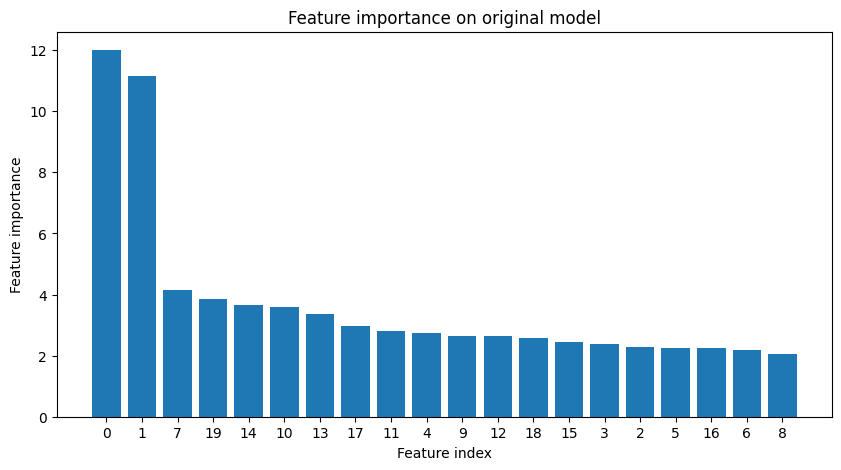

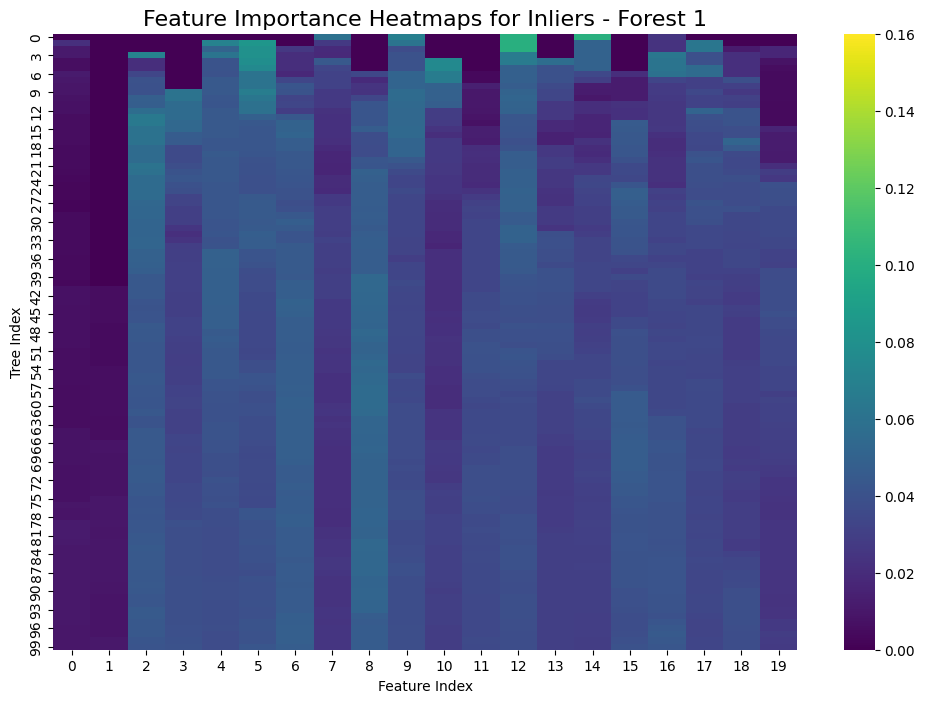

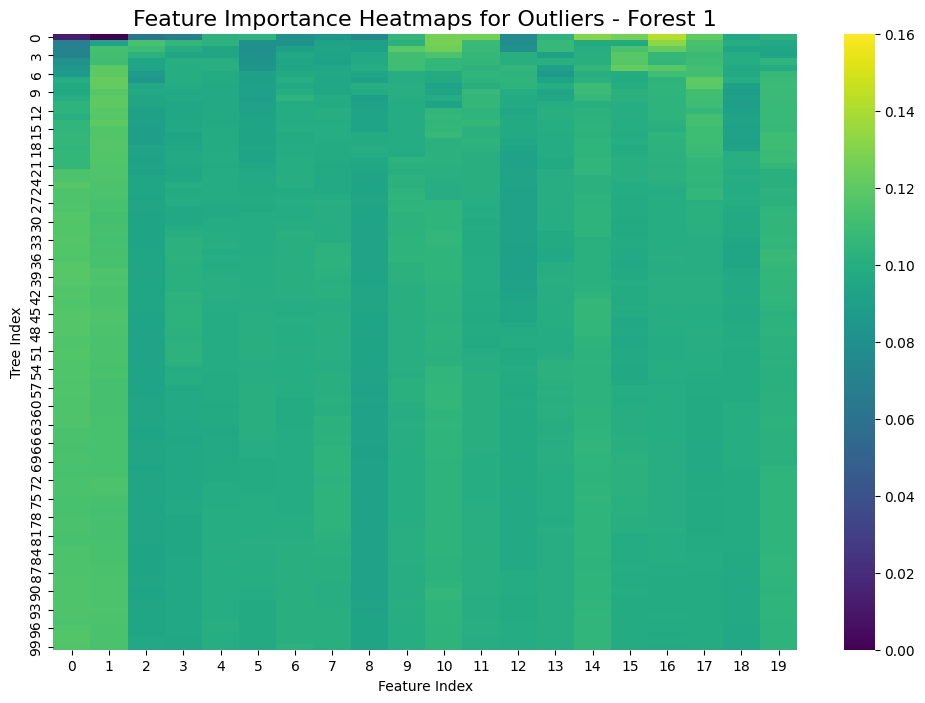

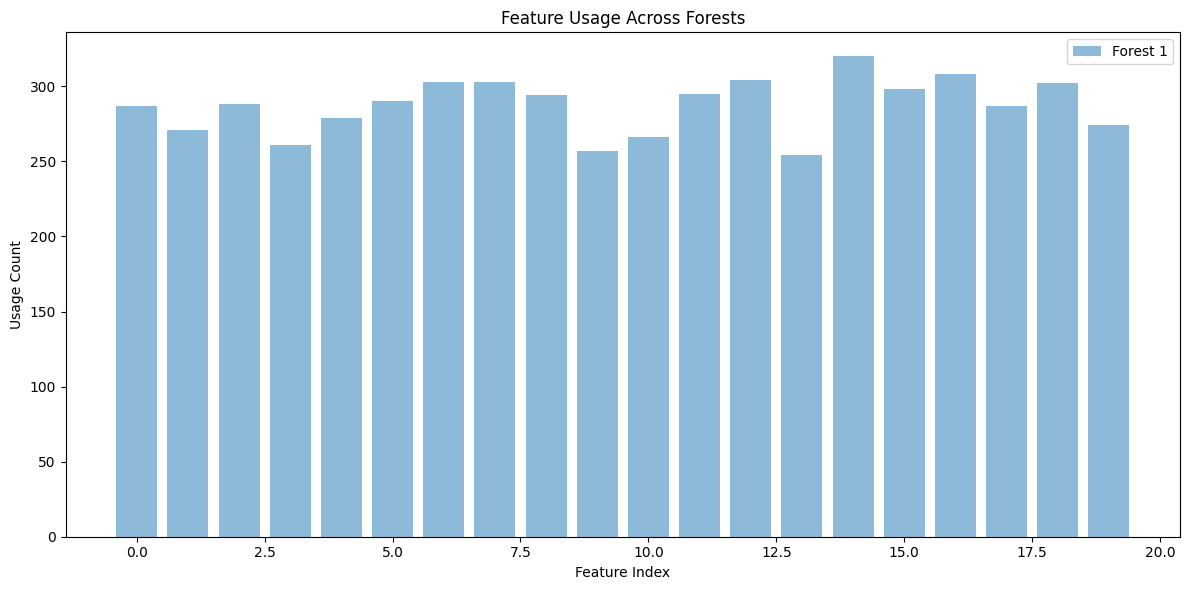

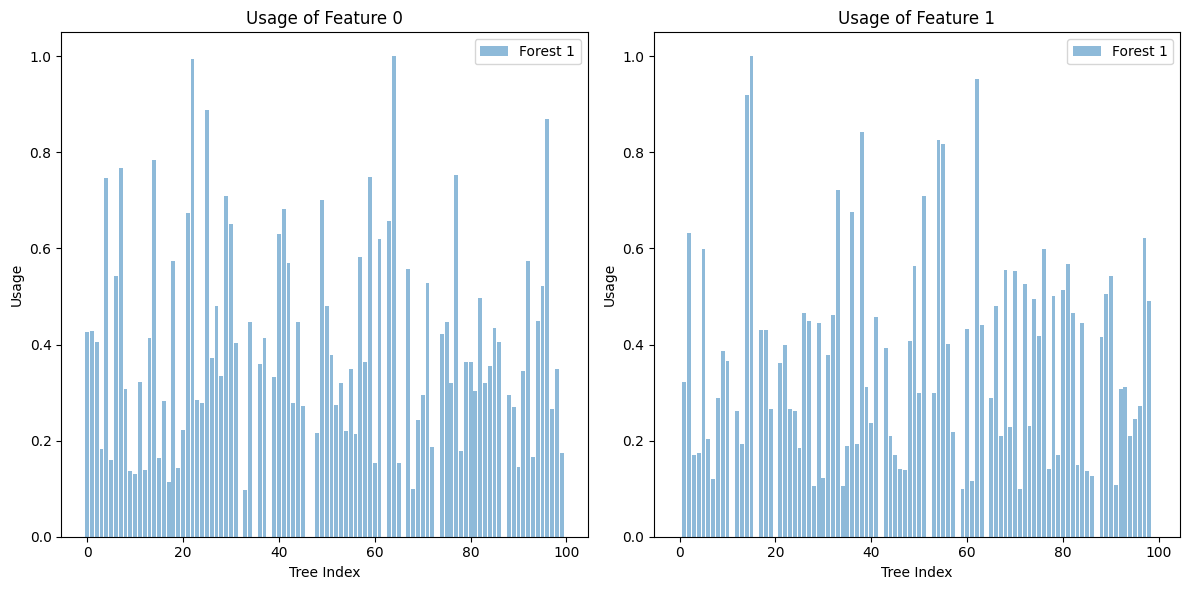

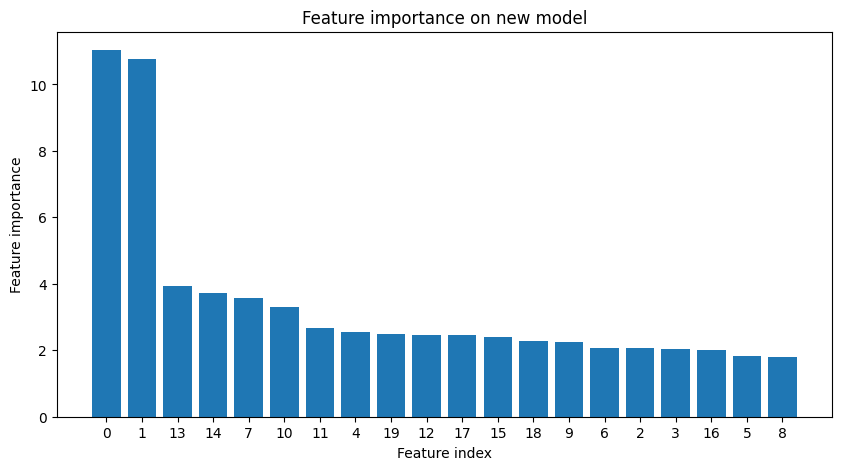

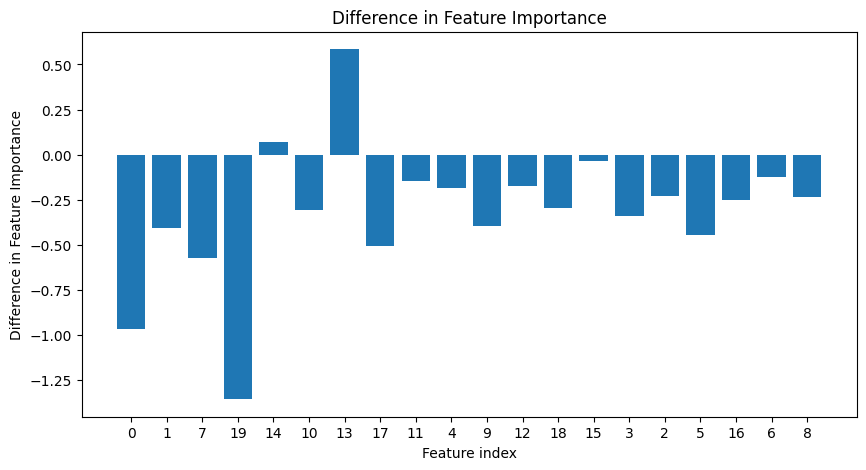

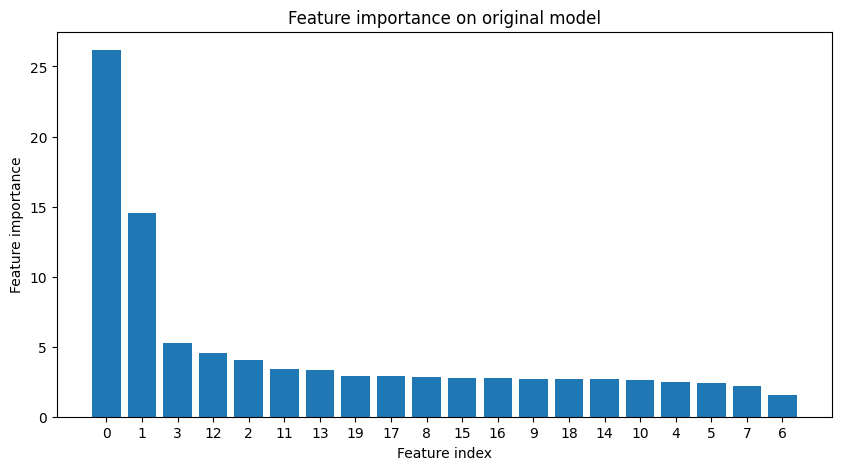

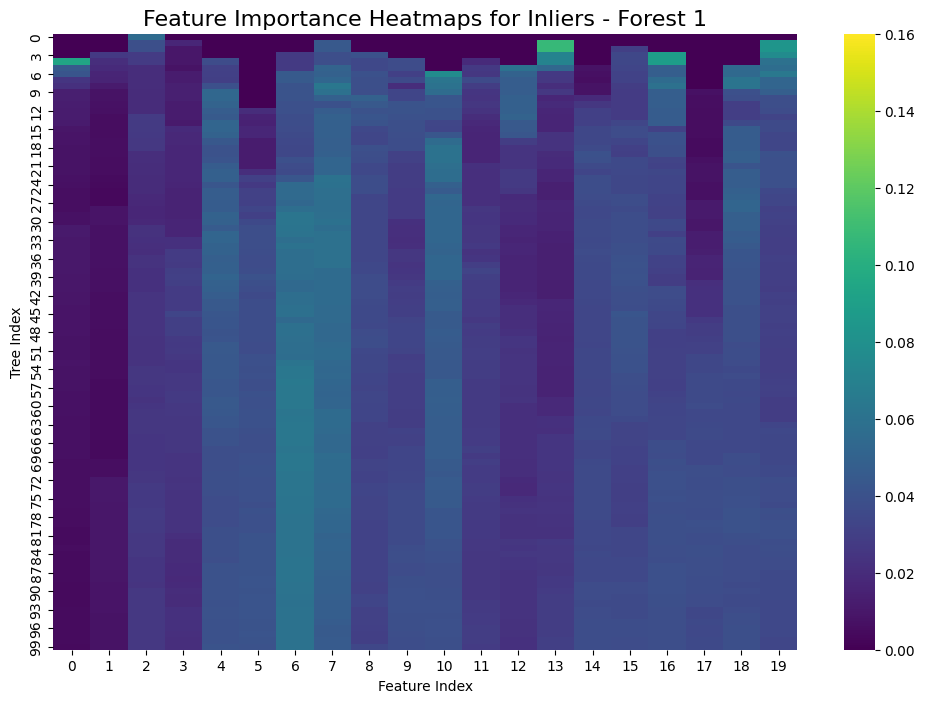

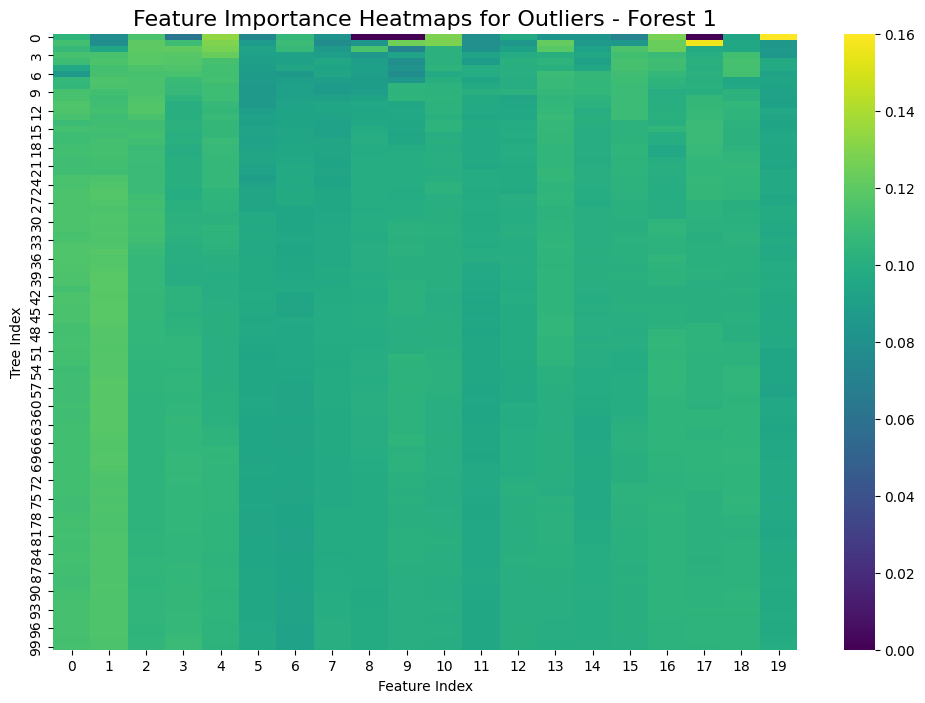

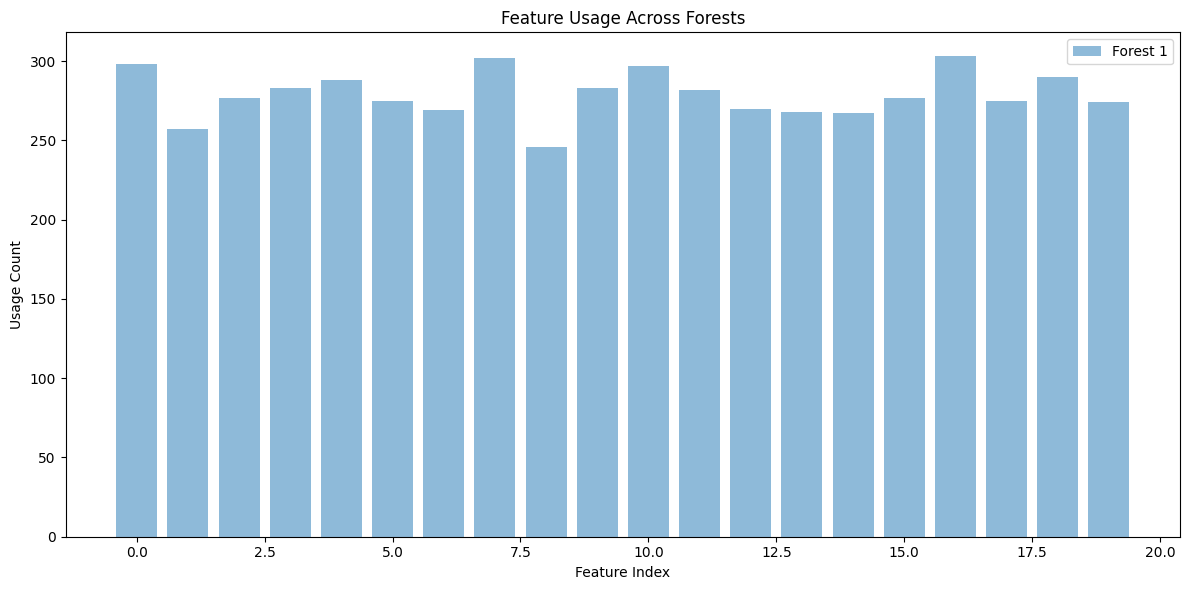

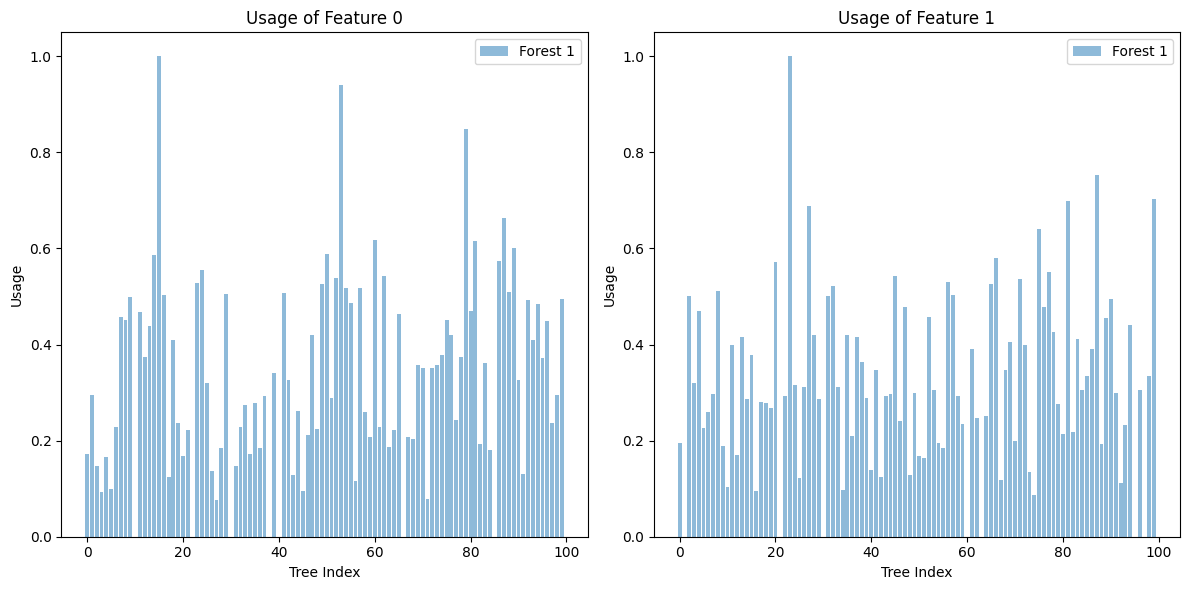

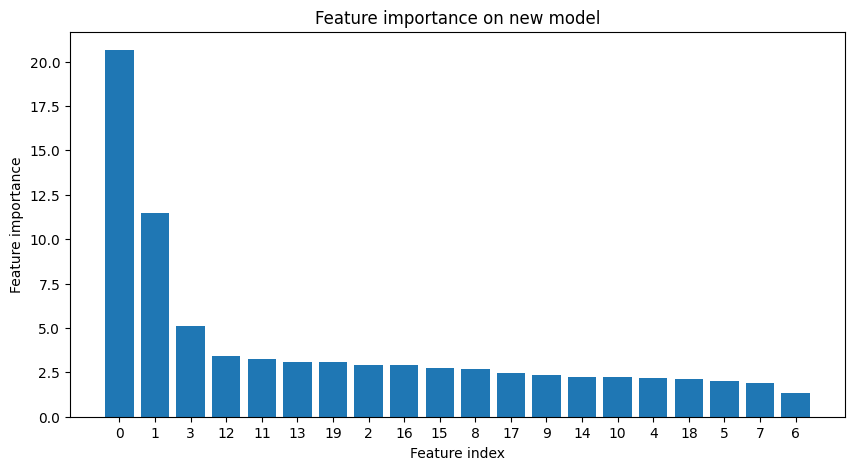

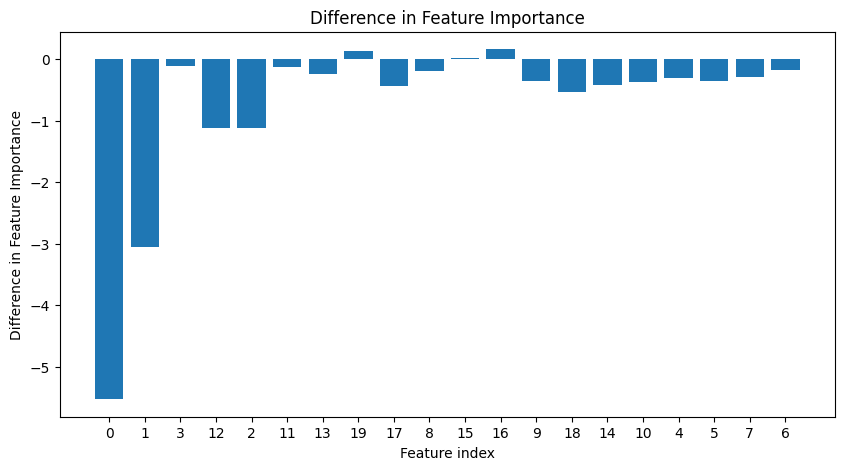

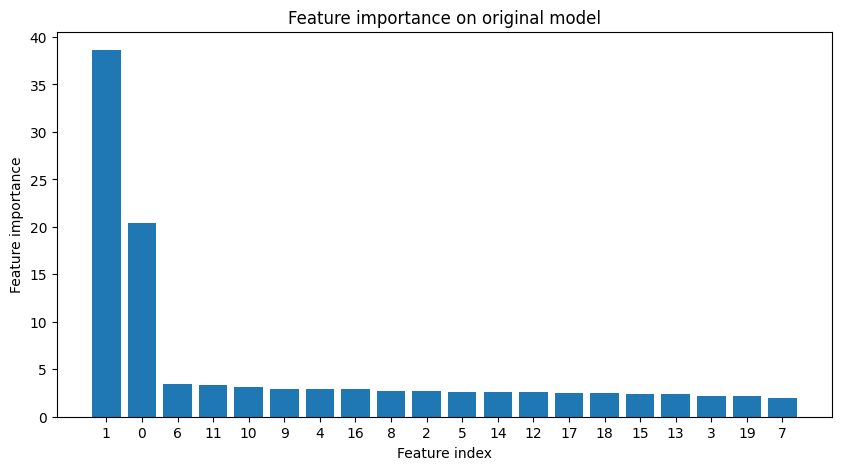

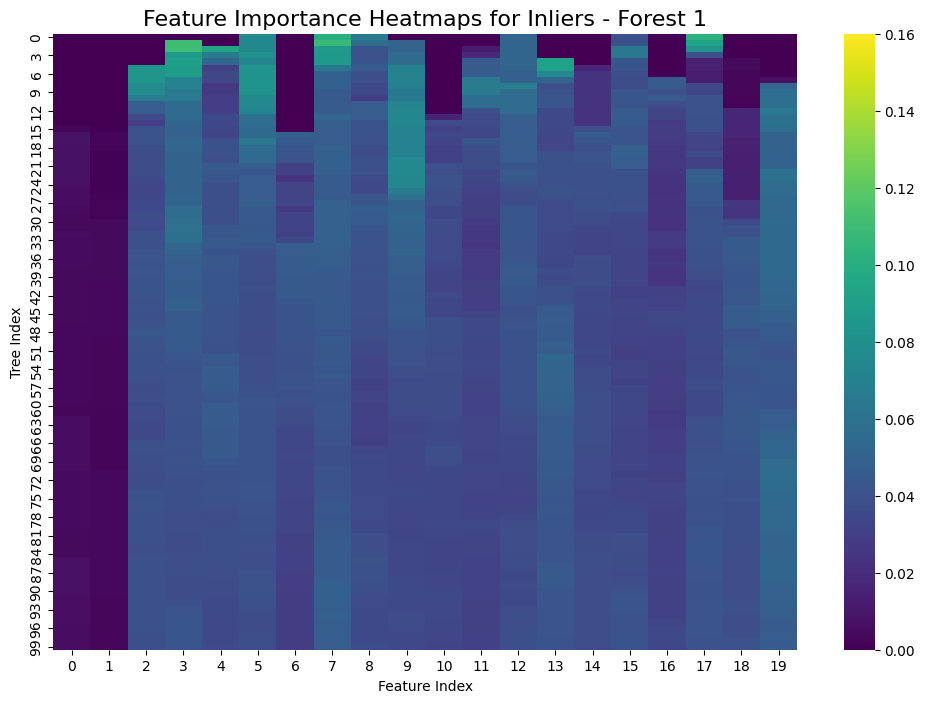

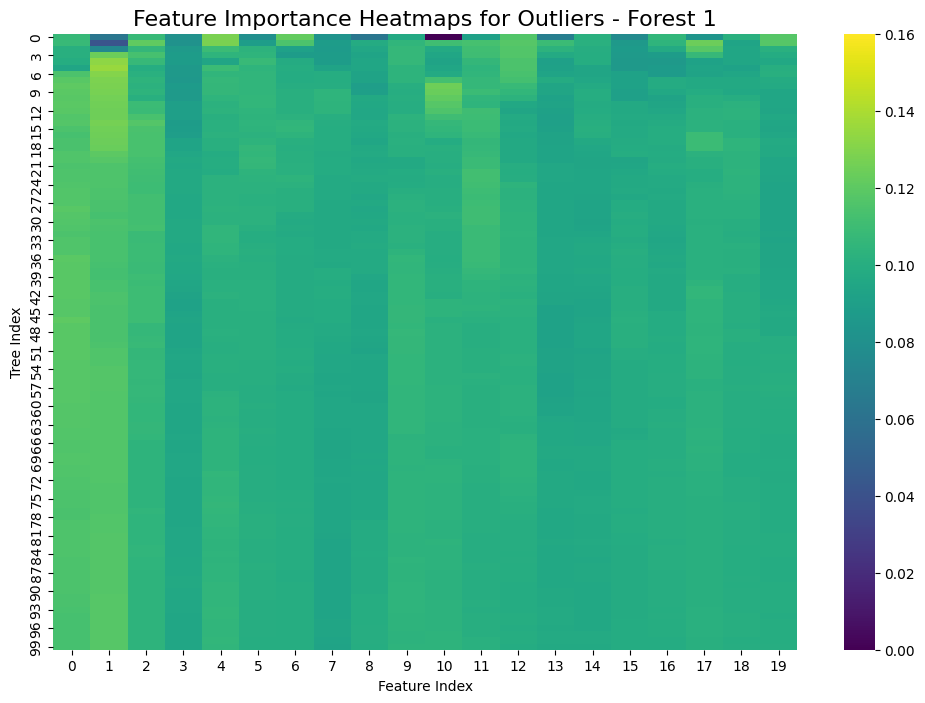

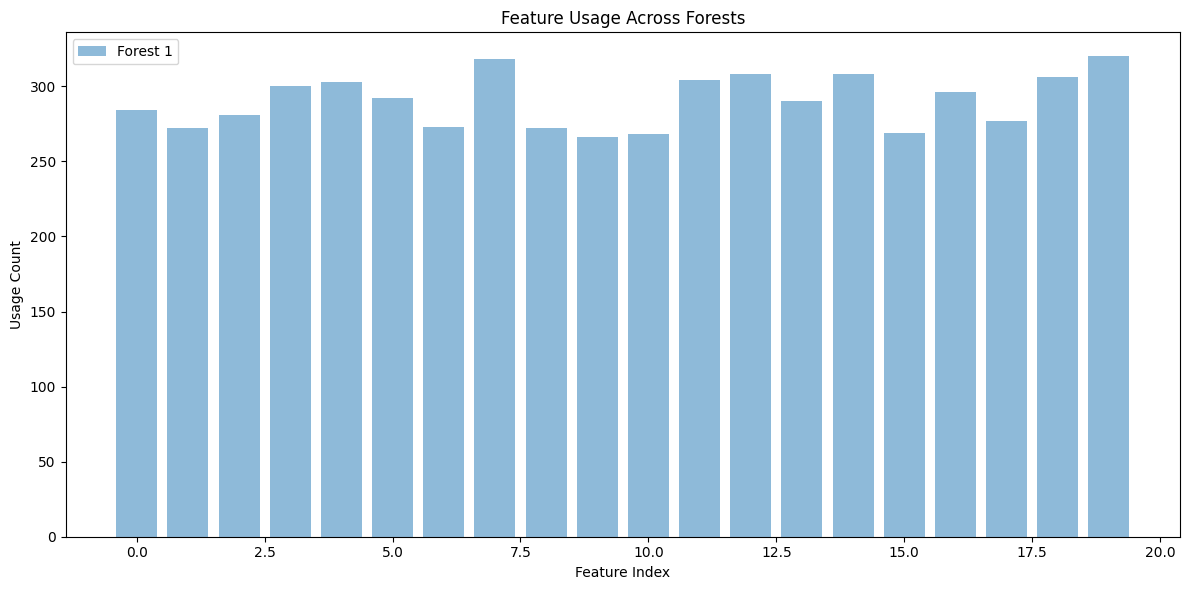

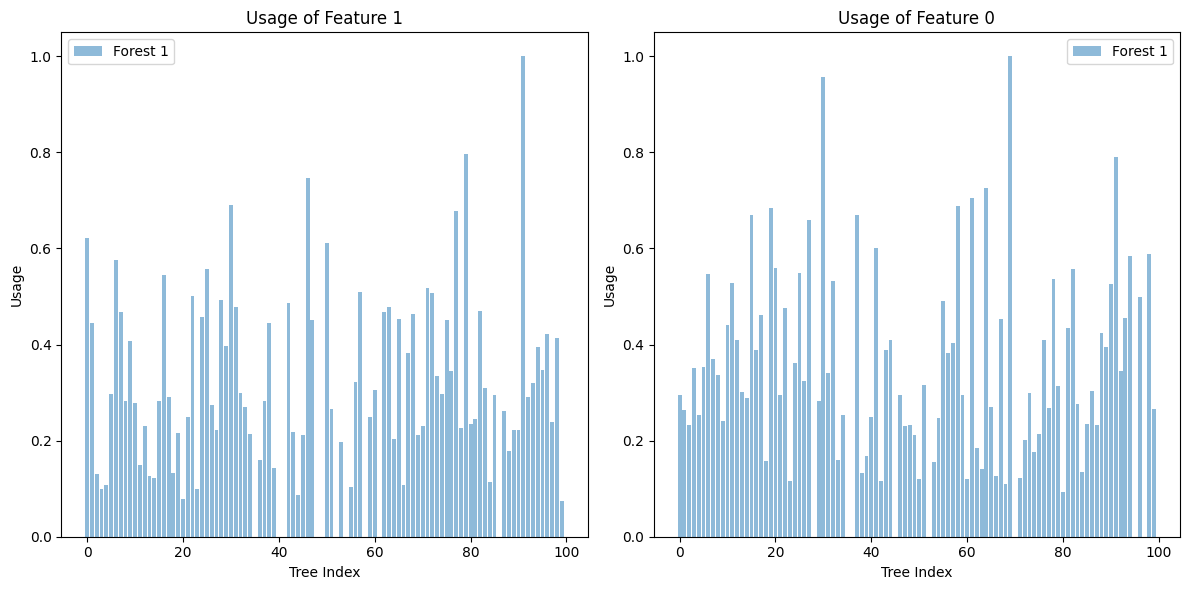

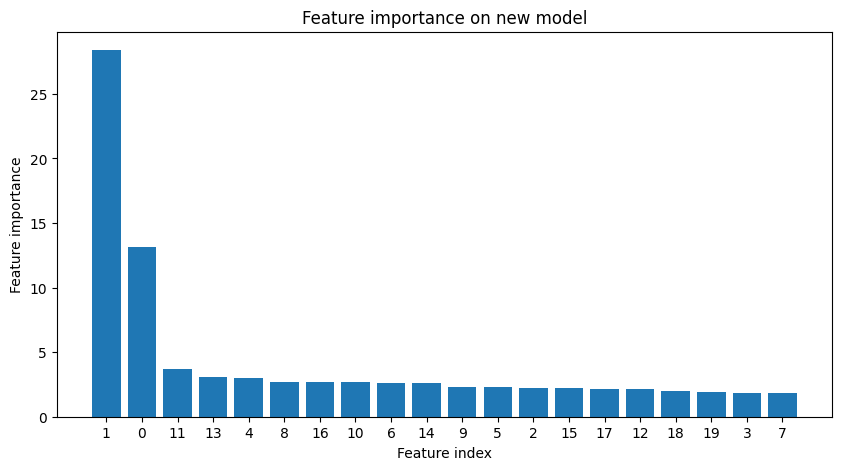

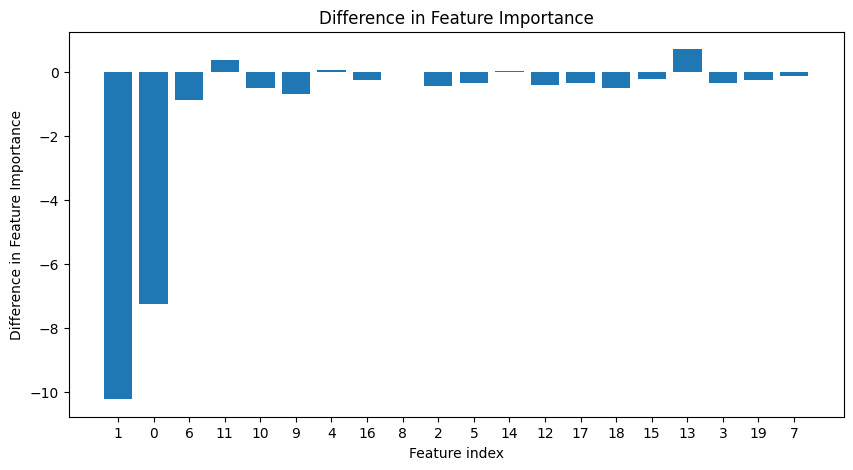

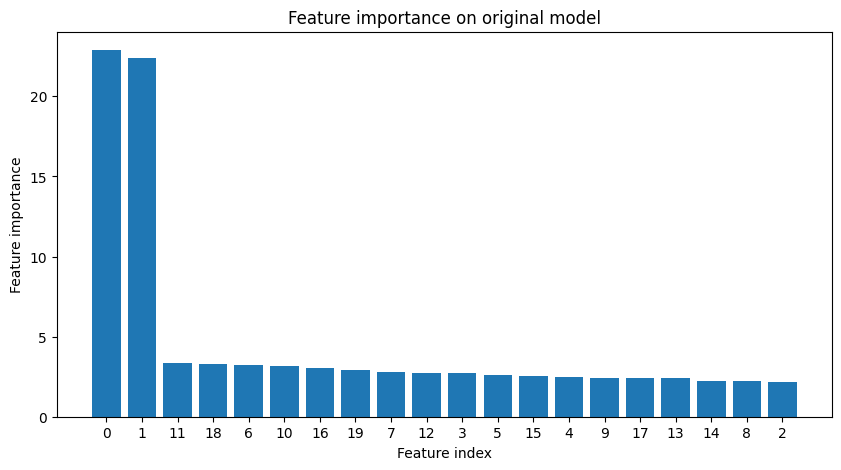

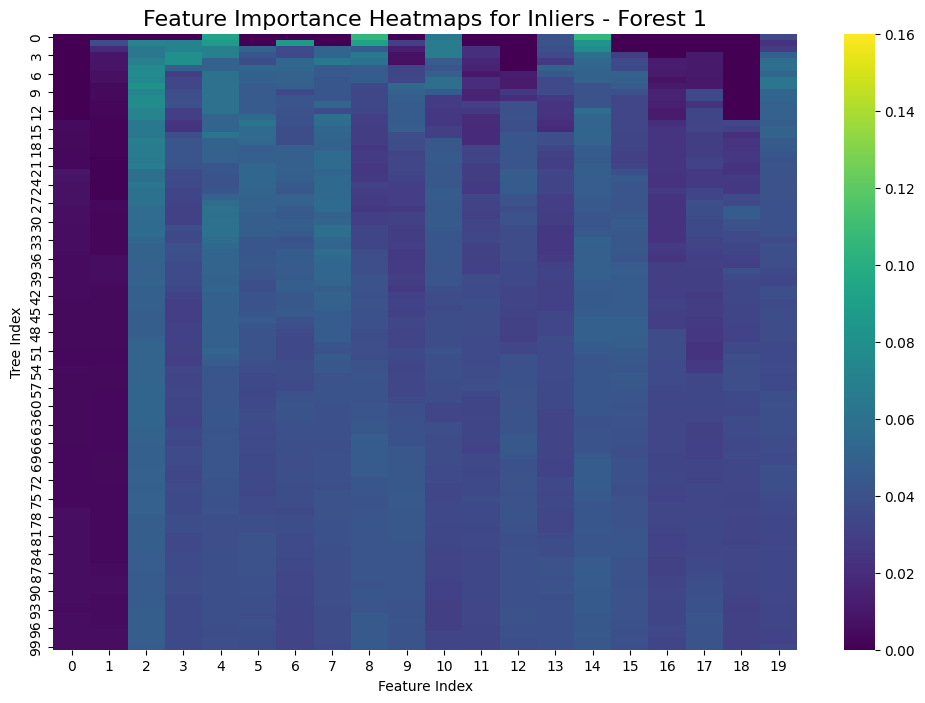

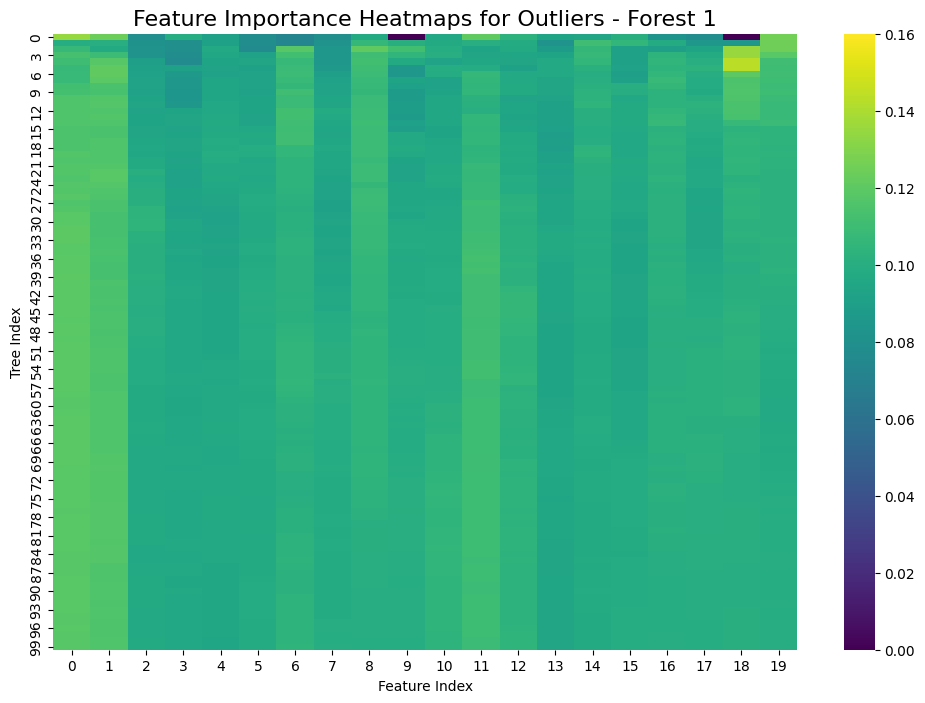

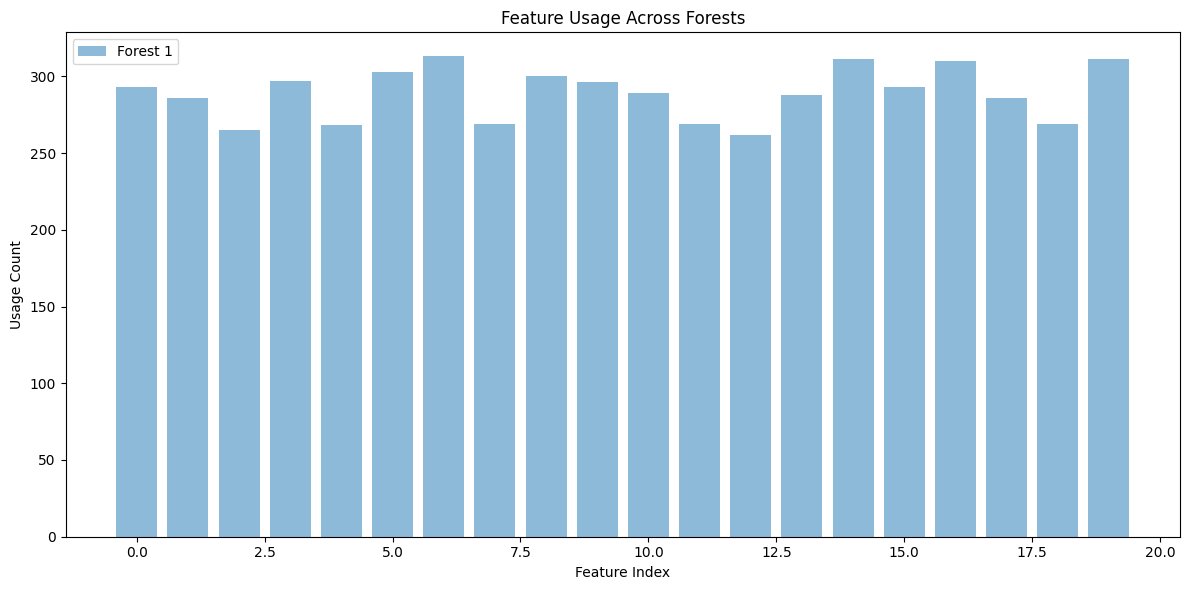

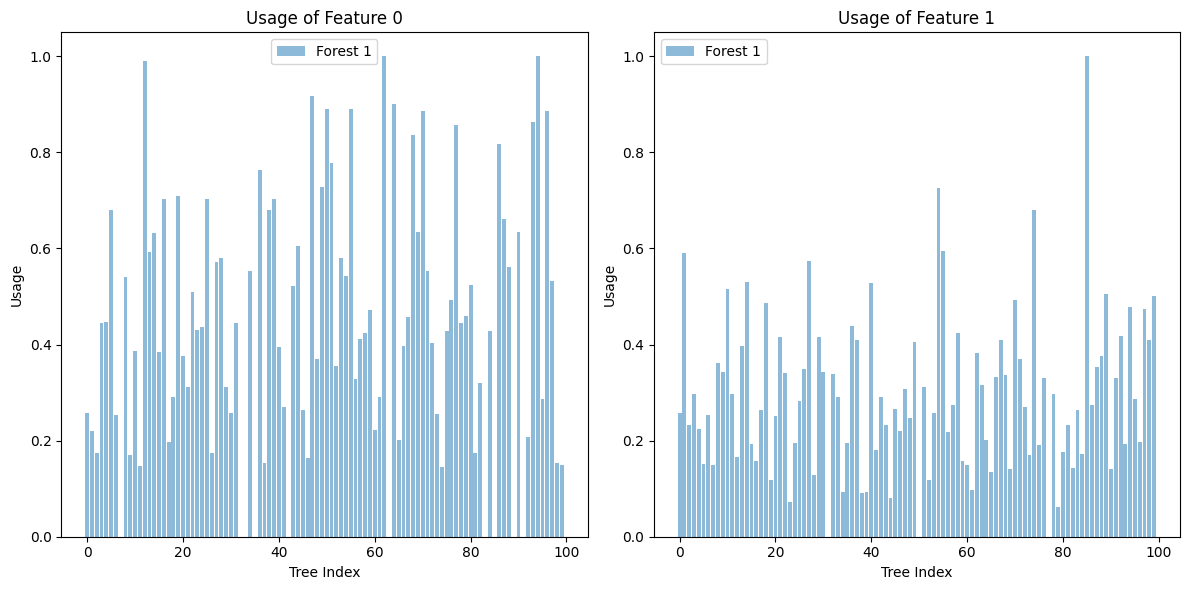

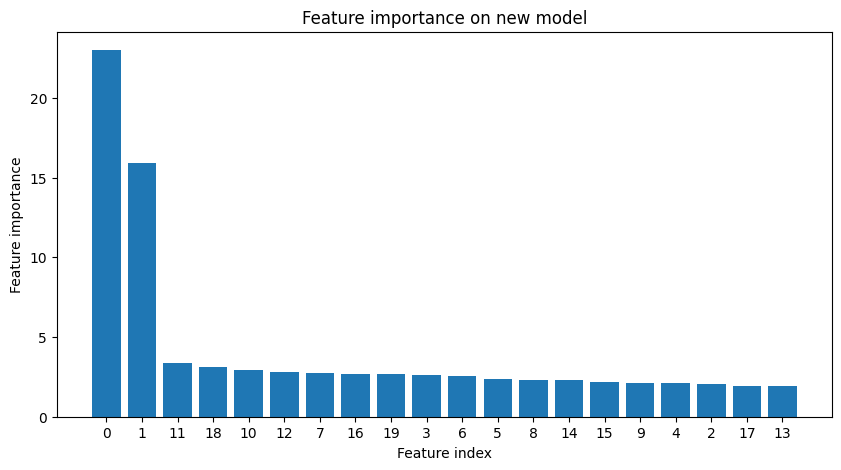

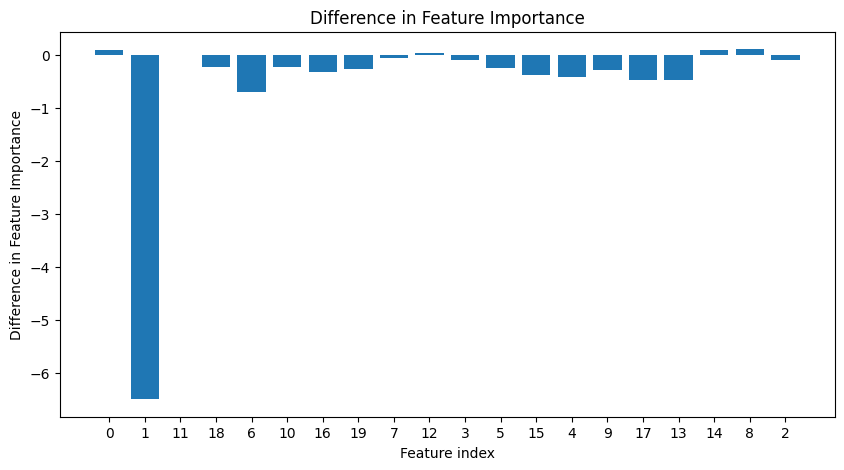

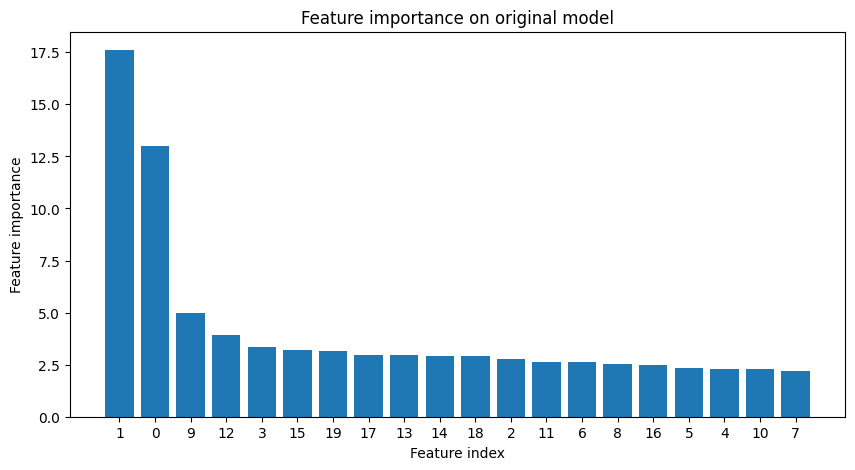

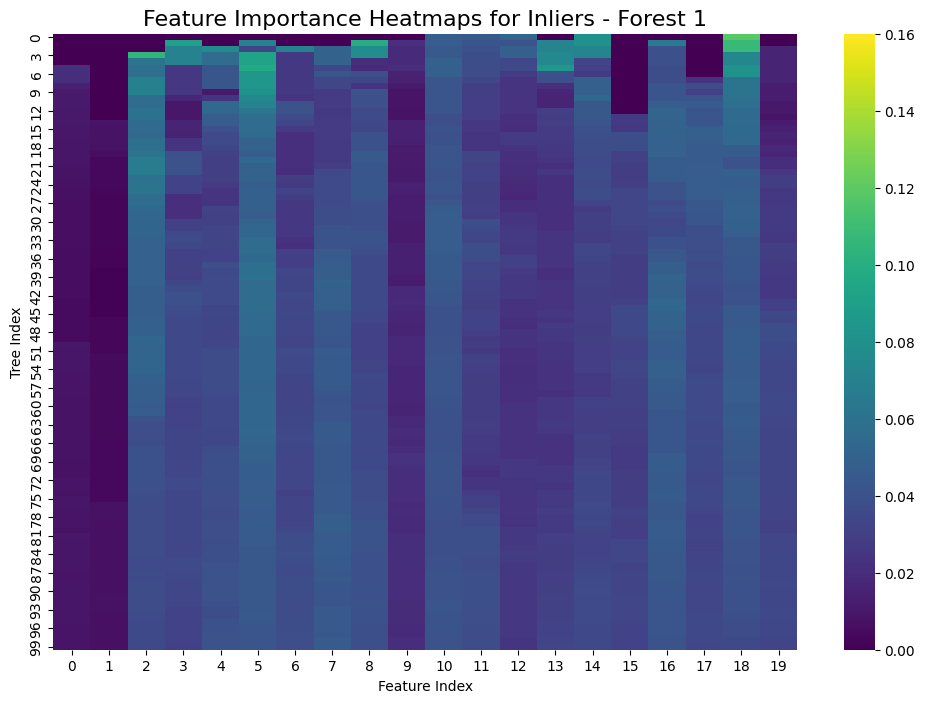

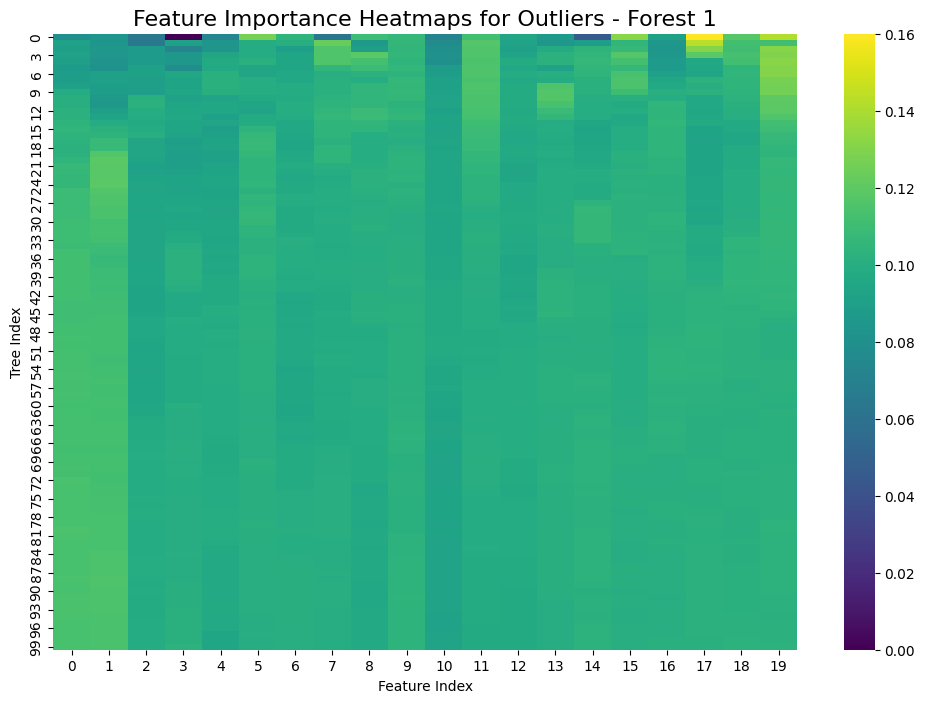

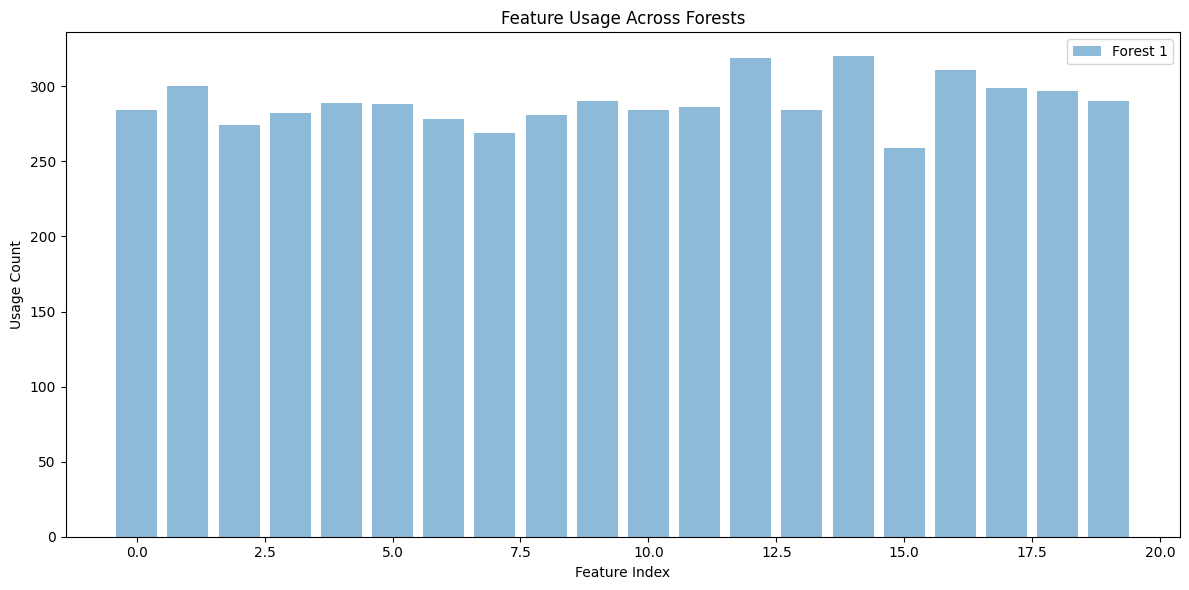

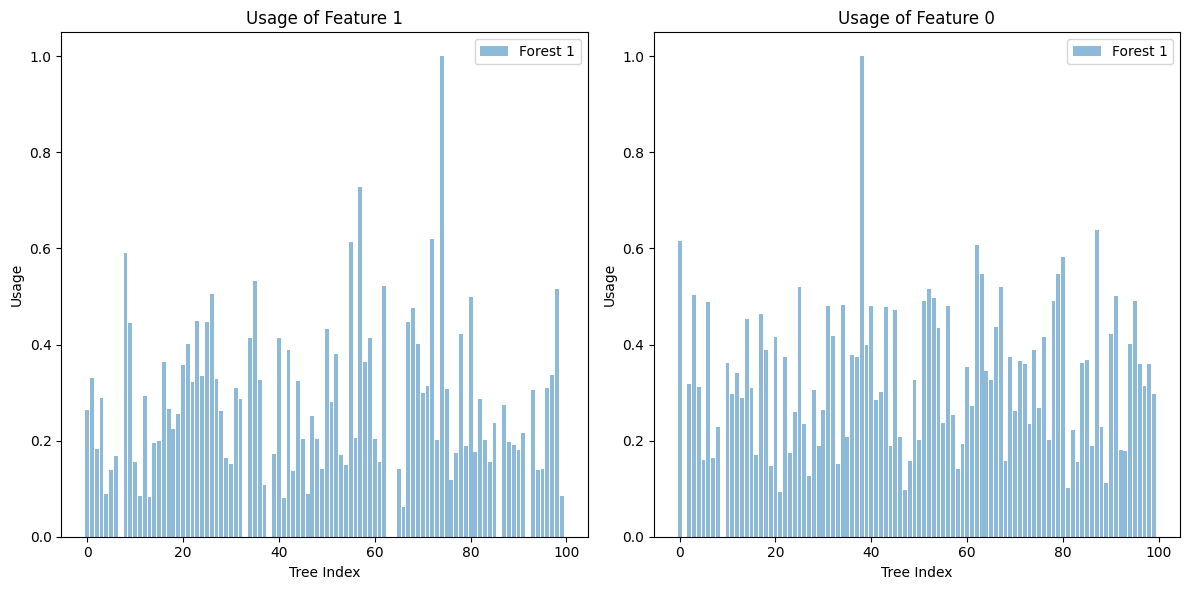

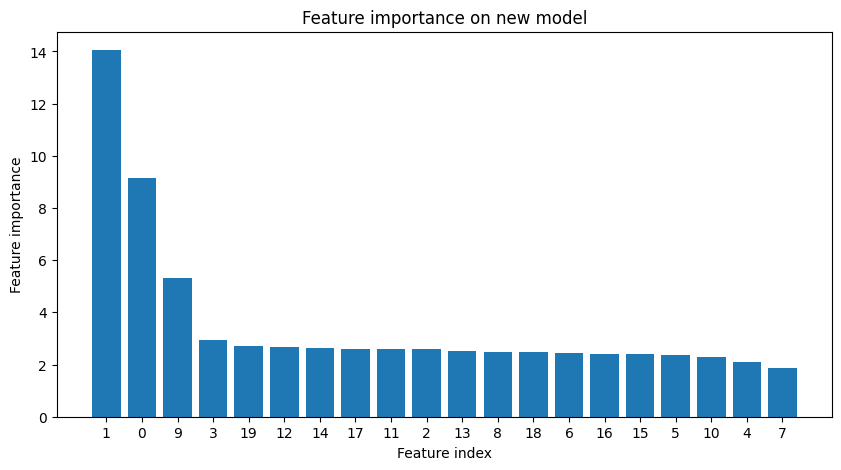

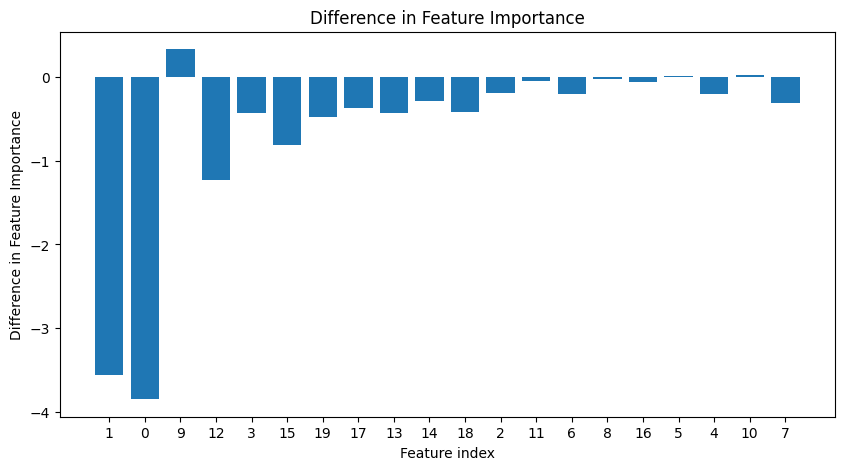

In [16]:
for seed in [0, 1, 2, 3, 4]:
    print(f"Seed: {seed}\n")

    # Load synthetic dataset
    data, labels, contamination = generate_syn_dataset()

    X_tr, X_te, y_tr, y_te = train_test_split(data, labels, test_size=0.1, random_state=seed)

    # for i, dataset in enumerate(odds_datasets.datasets_names):
    #         X, y = odds_datasets.load(dataset)
    #         contamination = y.mean()
    #         X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=seed, stratify=y)

    X_tr, y_tr = shuffle(X_tr, y_tr, random_state=seed)

    print('Training set size: ', X_tr.shape)
    print('Trainin label size: ', y_tr.shape)

    print('Test set size: ', X_te.shape)
    print('Test label size: ', y_te.shape)

    print('\n')

    num_features = X_tr.shape[1]
    
    # Init wandb to log the results
    run = wandb.init(
        project="diffi_optimization",
        name=f"experiment_forest_{n_forests}_trees_{num_trees}_seed_{seed}",
        # job_type="training",
        config={
            "seed": seed,
            "dataset": "synthetic",     # change according to the dataset actually used
            "num_trees": num_trees,
            "max_samples": max_samples,
            "n_forests": n_forests,
            "contamination": contamination,
            "usage_threshold": 0.1,
        }
    )

    # TODO: compute also the average precision score
    sorted_idx, avg_f1, fi_means, fi_std, features_per_forest, fi_diffi_all, iforests, fi_diffi_inliers, fi_diffi_outliers = diffi_ranks_per_tree(
        X=X_tr, 
        y=y_tr, 
        n_trees=run.config.num_trees, 
        max_samples=run.config.max_samples, 
        n_iter=run.config.n_forests, 
        seed=seed,
        contamination=run.config.contamination) 
    
    # print('Feature per forest:', features_per_forest)
    
    # [print(f"Feature {sorted_idx[i]}: FI mean - {fi_means[i]}, FI std - {fi_std[i]}") for i in range(len(sorted_idx))]
    print('Feature importance means:', fi_means)

    # Normalize the feature importance with max-min normalization
    fi_means_normalized = (fi_means - np.min(fi_means)) / (np.max(fi_means) - np.min(fi_means))
    fi_std_normalized = (fi_std - np.min(fi_std)) / (np.max(fi_std) - np.min(fi_std))

    # [print(f"Feature {sorted_idx[i]}: Normalized FI mean - {fi_means[i]}, Normalized FI std - {fi_std[i]}") for i in range(len(sorted_idx))]
    
    print('Average F1 score: {:.4f}'.format(avg_f1))

    print('\n')
    
    num_forests = len(features_per_forest)
    num_trees = len(features_per_forest[0])
    
    log_model_config(run.config.contamination)

    log_feature_importance(sorted_idx, fi_means, fi_std, og_model=True)

    # Getting the most important features
    most_important_features = sorted_idx[:2]
    print('Most important features:', most_important_features)   

    print('\n')

    log_feature_importance_heatmap(fi_diffi_inliers, for_inliers=True)
    log_feature_importance_heatmap(fi_diffi_outliers, for_inliers=False)

    usage_per_forest, usage_per_tree = feature_usage(features_per_forest=features_per_forest, num_features=num_features)

    most_important_feature_usage_scaled = most_important_feature_usage(most_important_features=most_important_features,
                                                                            usage_per_tree=usage_per_tree, 
                                                                            features_per_forest=features_per_forest)
    

    most_important_features_fi_means = fi_means_normalized[most_important_features]
    print('Most important features scaled FI means:', most_important_features_fi_means)
    average_usage(most_important_feature_usage_scaled, most_important_features=most_important_features, seed_idx=seed, fi_means=most_important_features_fi_means)

    print('\n')

    removing_trees(
        most_important_feature_usage_scaled, 
        most_important_features=most_important_features, 
        iforests=iforests, 
        # TODO: robustness check of the threshold shape
        threshold=usage_threshold[0]) 

    print('\n')

    #TODO: compute also the average precision score
    new_sorted_idx, new_avg_f1, new_fi_means, new_fi_std, new_features_per_forest, new_fi_diffi_all, new_fi_diffi_inliers, new_fi_diffi_outliers = diffi_ranks_evaluation_only(
        X=X_tr, y=y_tr, iforest=iforests) 

    print('New average F1 score: {:.4f}'.format(new_avg_f1))

    print('\n')

    log_feature_importance(new_sorted_idx, new_fi_means, new_fi_std, og_model=False)

    # TODO: issue on shape of new_fi_diffi_inliers, new_fi_diffi_outliers

    # log_feature_importance_heatmap(new_fi_diffi_inliers, for_inliers=True)
    # log_feature_importance_heatmap(new_fi_diffi_outliers, for_inliers=False)

    # Log number of estimators in each forest of the new model
    data = [[f"Forest {i+1}", len(iforests[i].estimators_)] for i in range(len(iforests))]
    columns = ["Forest", "Number of Estimators"]

    num_estimators_table = wandb.Table(data=data, columns=columns)

    run.log({"Number of Estimators Table in the new model": num_estimators_table})

    # Log the F1 scores
    data = [[seed, num_forests, avg_f1, new_avg_f1]]
    columns = ["Seed", "Forest", "Original F1 Score", "New F1 Score"]
    avg_f1_scores_table = wandb.Table(data=data, columns=columns)
    run.log({"F1 Scores Table": avg_f1_scores_table})

    # Log the feature importance difference
    compute_difference(fi_means, new_fi_means, sorted_idx)

    print("---------------------------------------------------------------------------")

In [17]:
run.finish()